In [1]:
import pandas as pd
import csv

df = pd.read_csv("pilot6.csv", delimiter = ";")
df.head()

,id,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,timestamp_katja,flagged_katja,comment_katja,tag_katja,rev_tamara,rev_anze,rev_katja,final_tag
0,401,"Pomenljivo je, da je v poročilu 2014–2015 nave...",2023/03/23 10:10:03,NaN,"No direct opinion, but theme and sentiment beh...",N_Neutral,2023/03/23 9:00:13,NaN,No opinion. But on more negativ side,N_Neutral,2023/03/23 10:09:25,NaN,Pomenljivo je...,N_Neutral,NaN,NaN,NaN,NaN
1,402,"Enostavno se mi zdi, da ta argument, ki kakork...",2023/03/23 10:10:52,NaN,"Clearly expressed opinion,with negative sentim...",Negative,2023/03/23 9:00:47,NaN,Opinion on negativ side,Negative,2023/03/23 10:09:45,NaN,NaN,Negative,NaN,NaN,NaN,NaN
2,403,"In, recimo, v Kolumbiji imajo 700 takih, bi re...",2023/03/23 10:13:19,NaN,I think that the first part is negative (theme...,M_Positive,2023/03/23 9:01:22,NaN,"Weak opinion, but very negativ topic, so Negativ",Negative,2023/03/23 10:10:26,NaN,NaN,M_Positive,NaN,NaN,NaN,NaN
3,404,Druga sprememba se nanaša na potrjevanje učben...,2023/03/23 10:15:06,NaN,"No opinion, nothing really negative.",P_Neutral,2023/03/23 9:02:09,NaN,"No opinion, but topic is positiv",P_Neutral,2023/03/23 10:10:55,NaN,"Statement, nothing inherently negative",P_Neutral,NaN,NaN,NaN,NaN
4,405,"In tudi osebno mislim, da kulturna politika že...",2023/03/23 10:16:14,NaN,"Personal opinion, positive sentiment.",Positive,2023/03/23 9:21:41,NaN,Opinion in positiv side,Positive,2023/03/23 10:11:33,NaN,"Expressed opinion(osebno mislim), positive con...",Positive,NaN,NaN,NaN,NaN


# 6-level schema analysis

In [2]:
df1 = df.filter(['id', 'text', 'tag_tamara', 'tag_anze', 'tag_katja'])
df1

,id,text,tag_tamara,tag_anze,tag_katja
0,401,"Pomenljivo je, da je v poročilu 2014–2015 nave...",N_Neutral,N_Neutral,N_Neutral
1,402,"Enostavno se mi zdi, da ta argument, ki kakork...",Negative,Negative,Negative
2,403,"In, recimo, v Kolumbiji imajo 700 takih, bi re...",M_Positive,Negative,M_Positive
3,404,Druga sprememba se nanaša na potrjevanje učben...,P_Neutral,P_Neutral,P_Neutral
4,405,"In tudi osebno mislim, da kulturna politika že...",Positive,Positive,Positive
...,...,...,...,...,...
95,496,"Še sreča, da do tega ni prišlo med športno pri...",N_Neutral,N_Neutral,P_Neutral
96,497,"Kolikor se bo tisto uresničilo, kar sem prej p...",M_Negative,Negative,M_Positive
97,498,Javna naročila predstavljajo velik del porabe ...,P_Neutral,P_Neutral,P_Neutral
98,499,"S tem lahko ugotovimo, da nam bonitetne agenci...",P_Neutral,P_Neutral,Positive


In [3]:
from sklearn.metrics import cohen_kappa_score

annotator1 = df1['tag_tamara']
annotator2 = df1['tag_anze']
annotator3 = df1['tag_katja']

#CK Tamara-Anže
cohen_kappa_score(annotator1, annotator2)

0.4861392832995267

In [4]:
#CK Anže-Katja
cohen_kappa_score(annotator2, annotator3)

0.23904487011283126

In [5]:
#CK Tamara-Katja
cohen_kappa_score(annotator1, annotator3)

0.5896757114493713

In [6]:
score1 = cohen_kappa_score(annotator1, annotator2)
score2 = cohen_kappa_score(annotator2, annotator3)
score3 = cohen_kappa_score(annotator1, annotator3)
score = (score1 + score2 + score3)/3
score

0.43828662162057636

In [7]:
df2 = df1.filter(['tag_tamara', 'tag_anze', 'tag_katja'])
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(df2)

    tag_tamara    tag_anze   tag_katja
0    N_Neutral   N_Neutral   N_Neutral
1     Negative    Negative    Negative
2   M_Positive    Negative  M_Positive
3    P_Neutral   P_Neutral   P_Neutral
4     Positive    Positive    Positive
5    N_Neutral   N_Neutral   N_Neutral
6    P_Neutral   P_Neutral   P_Neutral
7     Negative    Negative    Negative
8     Negative   N_Neutral    Negative
9     Negative   N_Neutral    Negative
10   N_Neutral   N_Neutral   N_Neutral
11   P_Neutral   P_Neutral   P_Neutral
12   P_Neutral    Positive   P_Neutral
13   P_Neutral    Positive   P_Neutral
14   P_Neutral   P_Neutral   P_Neutral
15   N_Neutral    Positive   N_Neutral
16    Negative   N_Neutral    Negative
17    Positive   P_Neutral    Positive
18   N_Neutral    Negative    Positive
19   P_Neutral    Negative   P_Neutral
20    Negative    Negative    Negative
21    Positive    Positive    Positive
22   P_Neutral   P_Neutral  M_Positive
23    Negative    Negative    Negative
24    Negative   N_Neutra

In [8]:
values_tamara = df1['tag_tamara'].value_counts()
values_tamara

N_Neutral     36
P_Neutral     26
Negative      24
Positive      11
M_Positive     2
M_Negative     1
Name: tag_tamara, dtype: int64

In [9]:
values_anze = df1['tag_anze'].value_counts()
values_anze

N_Neutral     35
P_Neutral     25
Negative      21
Positive      17
M_Positive     2
Name: tag_anze, dtype: int64

In [10]:
values_katja = df1['tag_katja'].value_counts()
values_katja

Negative      34
P_Neutral     26
N_Neutral     22
Positive      14
M_Positive     3
M_Negative     1
Name: tag_katja, dtype: int64

<AxesSubplot:>

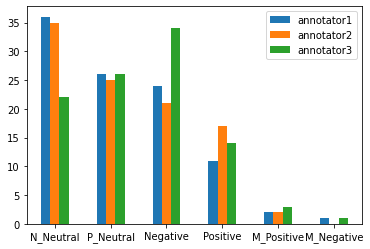

In [11]:
annotator1 = [36, 26, 24, 11, 2, 1]
annotator2 = [35, 25, 21, 17, 2, 0]
annotator3 = [22, 26, 34, 14, 3, 1]
index = ['N_Neutral', 'P_Neutral', 'Negative', 'Positive', 'M_Positive', 'M_Negative']

df2 = pd.DataFrame({'annotator1': annotator1, 'annotator2': annotator2, 'annotator3': annotator3}, index = index)
df2.plot.bar(rot=0)

# 3-level schema analysis

In [12]:
df1.loc[(df1['tag_tamara'] == 'Negative') | (df1['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df1.loc[(df1['tag_tamara'] == 'Positive') | (df1['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df1.loc[(df1['tag_tamara'] == 'P_Neutral') | (df1['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [13]:
df1.loc[(df1['tag_anze'] == 'Negative') | (df1['tag_anze'] == 'M_Negative'), 'sent_anze'] = 'Negative'
df1.loc[(df1['tag_anze'] == 'Positive') | (df1['tag_anze'] == 'M_Positive'), 'sent_anze'] = 'Positive'
df1.loc[(df1['tag_anze'] == 'P_Neutral') | (df1['tag_anze'] == 'N_Neutral'), 'sent_anze'] = 'Neutral'

In [14]:
df1.loc[(df1['tag_katja'] == 'Negative') | (df1['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df1.loc[(df1['tag_katja'] == 'Positive') | (df1['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df1.loc[(df1['tag_katja'] == 'P_Neutral') | (df1['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [15]:
df1.filter(['id', 'text', 'sent_tamara', 'sent_anze', 'sent_katja'])

,id,text,sent_tamara,sent_anze,sent_katja
0,401,"Pomenljivo je, da je v poročilu 2014–2015 nave...",Neutral,Neutral,Neutral
1,402,"Enostavno se mi zdi, da ta argument, ki kakork...",Negative,Negative,Negative
2,403,"In, recimo, v Kolumbiji imajo 700 takih, bi re...",Positive,Negative,Positive
3,404,Druga sprememba se nanaša na potrjevanje učben...,Neutral,Neutral,Neutral
4,405,"In tudi osebno mislim, da kulturna politika že...",Positive,Positive,Positive
...,...,...,...,...,...
95,496,"Še sreča, da do tega ni prišlo med športno pri...",Neutral,Neutral,Neutral
96,497,"Kolikor se bo tisto uresničilo, kar sem prej p...",Negative,Negative,Positive
97,498,Javna naročila predstavljajo velik del porabe ...,Neutral,Neutral,Neutral
98,499,"S tem lahko ugotovimo, da nam bonitetne agenci...",Neutral,Neutral,Positive


In [16]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
annotator3 = df1['sent_katja']
#Tamara - Anže
cohen_kappa_score(annotator1, annotator2)

0.364560639070443

In [17]:
# Anže - Katja
cohen_kappa_score(annotator2, annotator3)

0.15869350049488629

In [18]:
# Tamara - Katja
cohen_kappa_score(annotator1, annotator3)

0.6120107962213226

In [19]:
df3 = df1.filter(['sent_tamara', 'sent_anze', 'sent_katja'])
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       ):
    print(df3)

   sent_tamara sent_anze sent_katja
0      Neutral   Neutral    Neutral
1     Negative  Negative   Negative
2     Positive  Negative   Positive
3      Neutral   Neutral    Neutral
4     Positive  Positive   Positive
5      Neutral   Neutral    Neutral
6      Neutral   Neutral    Neutral
7     Negative  Negative   Negative
8     Negative   Neutral   Negative
9     Negative   Neutral   Negative
10     Neutral   Neutral    Neutral
11     Neutral   Neutral    Neutral
12     Neutral  Positive    Neutral
13     Neutral  Positive    Neutral
14     Neutral   Neutral    Neutral
15     Neutral  Positive    Neutral
16    Negative   Neutral   Negative
17    Positive   Neutral   Positive
18     Neutral  Negative   Positive
19     Neutral  Negative    Neutral
20    Negative  Negative   Negative
21    Positive  Positive   Positive
22     Neutral   Neutral   Positive
23    Negative  Negative   Negative
24    Negative   Neutral   Negative
25     Neutral   Neutral    Neutral
26    Negative   Neutral   N

In [20]:
sentiment_tamara = df1['sent_tamara'].value_counts()
sentiment_tamara

Neutral     62
Negative    25
Positive    13
Name: sent_tamara, dtype: int64

In [21]:
sentiment_anze = df1['sent_anze'].value_counts()
sentiment_anze

Neutral     60
Negative    21
Positive    19
Name: sent_anze, dtype: int64

In [22]:
sentiment_katja = df1['sent_katja'].value_counts()
sentiment_katja

Neutral     48
Negative    35
Positive    17
Name: sent_katja, dtype: int64

<AxesSubplot:>

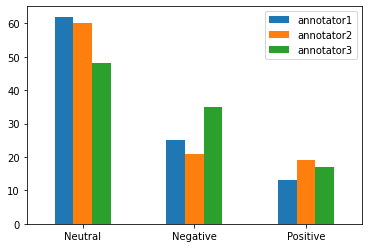

In [23]:
annotator1 = [62, 25, 13]
annotator2 = [60, 21, 19]
annotator3 = [48, 35, 17]
index = ['Neutral', 'Negative', 'Positive']

df4 = pd.DataFrame({'annotator1':annotator1, 'annotator2' : annotator2, 'annotator3':annotator3}, index = index)
df4.plot.bar(rot = 0)